In [1]:
import timeit as t
from timeit import default_timer as timer
import numpy as np
import matplotlib.pyplot as plt
#### %matplotlib notebook
%matplotlib inline

# Setup styles for plotting
style_list = ['default', 'classic'] + sorted(
        style for style in plt.style.available if style != 'classic')
plt.style.use(style_list[10])
print(style_list)

['default', 'classic', 'Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [23]:
# 2.1 Function to find Nth Fibonacci term
def FibonacciRec(N:int):
    # Base Case
    if (N < 2):
        return N

    # Recursively computing the term
    # using recurrence relation
    return FibonacciRec(N - 1) + FibonacciRec(N - 2)

# Test fibonacci: compute results for N 1 .. 20
for i in range(1,20):
    f10 = FibonacciRec(i)
    print(f10)


1
1
2
3
5
8
13
21
34
55
89
144
233
377
610
987
1597
2584
4181


### 2.1 Merjenje časa izvajanja
Za pravilno meritev časa izvajanja bomo uporabljali funkcijo `timeit()`, namenjeno testiranju hitrosti manjših koščkov kode. Uporablja se na naslednji način, primer:
`t.timeit('quicksort(data)','from __main__ import data,quicksort', number = num)`

Prvi niz je ukaz, ki ga merimo, nato drugi niz definira importe oziroma knjižnice, nato pa še, kolikokrat želimo izvesti ta ukaz (večkrat je bolj zanesljiva meritev časa). 

In [25]:
# Measure execution time : 
fibNumber = 40

t_fib = t.timeit('FibonacciRec(fibNumber)','from __main__ import fibNumber, FibonacciRec', number = 1)

print('Fibonnaci for ', fibNumber, ' execution time sec: ', t_fib)

Fibonnaci for  40  execution time sec:  18.827805800014175


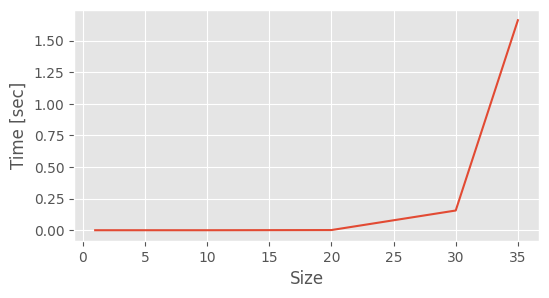

In [27]:
# 2.3 Plot graph of Fibonnaci execution time

size = np.array([]); #this array will store the current dataset size
t_list = np.array([]); #store processing time here
num = 1 #evaluation repetition (keep at 1 for now)

n_list = [1,3,5,10,20,30,35]
# zanka
for n in n_list:
    fibNumber = n
    t_fib = t.timeit('FibonacciRec(fibNumber)','from __main__ import fibNumber, FibonacciRec', number = 1)
    t_list = np.append(t_list, t_fib)

ax = plt.figure(figsize=[6,3])
plt.plot(n_list, t_list)
plt.xlabel('Size')
plt.ylabel('Time [sec]')
plt.show()


In [28]:
# 2.4 Class for algorithm testing
from utils import Algorithm

# Testing
a = Algorithm()



In [32]:
# 2.5  Fibonnaci algoritem z uporabo Alogrithm
# Prva verzija, kjer je N dolocen s stevilom ponovitev

class FibonacciRecursion(Algorithm):
    def __init__(self):
        self.name = "FibonacciRecursion"

    # Function to find Nth Fibonacci term
    def FibonacciR(self, N:int):
        # Count each call of the function
        self.count_op += 1

        # Base Case
        if (N < 2):
            return N

        # Recursively computing the term
        # using recurrence relation
        return self.FibonacciR(N - 1) + self.FibonacciR(N - 2)

    def run_once(self):

        N = self.data_params['N']
        self.result_data = self.FibonacciR(N)

        return self.result_data


s = FibonacciRecursion()
s.data_params = {'N': 30}
print('Test result: ', s.run(3))


 >>  0 , msec: 388.135 , operations:  2692537
 >>  1 , msec: 395.035 , operations:  2692537
 >>  2 , msec: 385.553 , operations:  2692537
 >>>  FibonacciRecursion  > Total run() sec:  1.1695302999578416  Avg iter msec: 389.84343331928056
Test result:  {'name': 'FibonacciRecursion', 'avg_msec': 389.84343331928056, 'avg_O': 2692537.0, 'niter': 3, 'output': 832040}


 >>  0 , msec: 0.006 , operations:  1
 >>>  FibonacciRecursion  > Total run() sec:  0.000166199984960258  Avg iter msec: 0.166199984960258
 >>  0 , msec: 0.003 , operations:  5
 >>>  FibonacciRecursion  > Total run() sec:  3.15000070258975e-05  Avg iter msec: 0.0315000070258975
 >>  0 , msec: 0.005 , operations:  15
 >>>  FibonacciRecursion  > Total run() sec:  2.9699993319809437e-05  Avg iter msec: 0.029699993319809437
 >>  0 , msec: 0.024 , operations:  177
 >>>  FibonacciRecursion  > Total run() sec:  4.900002386420965e-05  Avg iter msec: 0.04900002386420965
 >>  0 , msec: 0.271 , operations:  1973
 >>>  FibonacciRecursion  > Total run() sec:  0.00030049995984882116  Avg iter msec: 0.30049995984882116
 >>  0 , msec: 3.849 , operations:  21891
 >>>  FibonacciRecursion  > Total run() sec:  0.003904599929228425  Avg iter msec: 3.904599929228425
 >>  0 , msec: 55.468 , operations:  242785
 >>>  FibonacciRecursion  > Total run() sec:  0.05555679998360574  Avg iter msec: 55.55679998360574

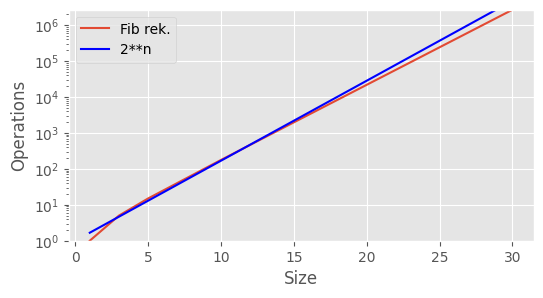

In [50]:
# 2.6 Testing Fibonacci recursion

size = np.array([]) #this array will store the current dataset size
t_list = np.array([]) #store processing time here
oper_list = np.array([]) #store processing operations here
num = 1 # evaluation repetition (keep at 1 for now)

n_list = [1,3,5,10,15,20,25,30]

s = FibonacciRecursion()
s.data_params = {'N': 1}

for n in n_list:
    s.data_params['N'] = n
    result = s.run(ntimes=num)
    size = np.append(size, n)
    oper_list = np.append(oper_list, result['avg_O'])



ax = plt.figure(figsize=[6,3])
plt.plot(n_list, oper_list, label='Fib rek.')

O2n = [np.float_power(1.67, n) for n in n_list]
plt.plot(n_list, O2n, 'b', label='2**n')

plt.ylim(1, max(oper_list))
plt.yscale('log')
plt.xlabel('Size')
plt.ylabel('Operations')
plt.legend()

plt.show()

In [44]:
# 2.7 Fibonnaci algorithm optimized

class FibonacciOptimized(Algorithm):
    def __init__(self):
        self.name = "FibonacciOptimized"

    # Function to find Nth Fibonacci term
    def Fibonacci(self, N):
        f=[0]*(N + 2)
        # 0th and 1st number of the
        # series are 0 and 1
        f[0] = 0
        f[1] = 1
        # Iterate over the range [2, N]
        for i in range(2,N+1) :
            self.count_op += 1
            # Add the previous 2 numbers
            # in the series and store it
            f[i] = f[i - 1] + f[i - 2]
        # Return Nth Fibonacci Number
        return f[N]

    def run_once(self):

        N = self.data_params['N']
        self.result_data = self.Fibonacci(N)

        return self.result_data


s = FibonacciOptimized()
s.data_params = {'N': 10}
print(s.run(1))



 >>  0 , msec: 0.008 , operations:  9
 >>>  FibonacciOptimized  > Total run() sec:  9.560002945363522e-05  Avg iter msec: 0.09560002945363522
{'name': 'FibonacciOptimized', 'avg_msec': 0.09560002945363522, 'avg_O': 9.0, 'niter': 1, 'output': 55}


 >>  0 , msec: 0.005 , operations:  0
 >>>  FibonacciOptimized  > Total run() sec:  0.00028220005333423615  Avg iter msec: 0.28220005333423615
 >>  0 , msec: 0.003 , operations:  2
 >>>  FibonacciOptimized  > Total run() sec:  2.510007470846176e-05  Avg iter msec: 0.02510007470846176
 >>  0 , msec: 0.002 , operations:  4
 >>>  FibonacciOptimized  > Total run() sec:  2.2399937734007835e-05  Avg iter msec: 0.022399937734007835
 >>  0 , msec: 0.002 , operations:  9
 >>>  FibonacciOptimized  > Total run() sec:  2.1099927835166454e-05  Avg iter msec: 0.021099927835166454
 >>  0 , msec: 0.004 , operations:  14
 >>>  FibonacciOptimized  > Total run() sec:  2.7699978090822697e-05  Avg iter msec: 0.027699978090822697
 >>  0 , msec: 0.004 , operations:  19
 >>>  FibonacciOptimized  > Total run() sec:  2.4400069378316402e-05  Avg iter msec: 0.024400069378316402
 >>  0 , msec: 0.007 , operations:  24
 >>>  FibonacciOptimized  > Total run() sec:  3.2800016924738884e-05  Avg iter msec: 0.03280001692

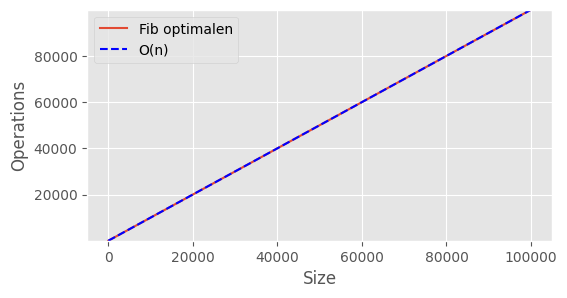

In [49]:
# 2.7 Testing Fibonacci optimized

size = np.array([]) #this array will store the current dataset size
t_list = np.array([]) #store processing time here
oper_list = np.array([]) #store processing operations here
num = 1 # evaluation repetition (keep at 1 for now)

n_list = [1,3,5,10,15, 20, 25, 30, 100, 1000, 10000, 100000]

s = FibonacciOptimized()
s.data_params = {'N': 1}

for n in n_list:
    s.data_params['N'] = n
    result = s.run(ntimes=num)
    size = np.append(size, n)
    oper_list = np.append(oper_list, result['avg_O'])

ax = plt.figure(figsize=[6,3])
plt.plot(n_list, oper_list, label='Fib optimalen')

#O2n = [np.float_power(1.67, n) for n in n_list]
#plt.plot(n_list, O2n, 'b', label='2**n')

Olin = [n for n in n_list]
plt.plot(n_list, Olin, 'b--', label='O(n)')

plt.ylim(1, max(oper_list))
plt.xlabel('Size')
plt.ylabel('Operations')
plt.legend()
plt.show()


### 3. Sortirni algoritmi

Testiramo in primerjamo delovanje različnih algoritmov sortiranja števil od najmanjšega do največjega. Pri tem imamo več scenarijev, glede na vhodne podatke:
* **optimalni**, v tem primeru so števila že urejena v želenem vrstnem redu
* **najslabši**, podatki so urejeni v obratnem vrstnem redu kot želimo
* **normalni**, podatki so urejeni naključno.


In [51]:
def insertionSort2(array):
    d = array.copy()
    for j in range(1, len(d)):
        key = d[j]
        i = j - 1
        while i >= 0 and d[i] > key:
            d[i + 1] = d[i]
            i = i - 1
        d[i + 1] = key
    return d

In [52]:
# Vrne set podatkov
def createSet(type = None, size = 100):
    if type == 1:  #return numbers sorted in ascening order -> best case
        return np.linspace(1,size,size).tolist() 
    elif type == 2: #return numbers in descending order -> wost case
        return np.linspace(size,1,size).tolist()
    else: #return a random assortment of numbers
        return (np.trunc(np.absolute(size*10/2.0 + size*10/5.0*np.random.randn(size)))/10).tolist()

In [55]:
# 3.1 Preskus parametrov type, size: izpiši dobljene podatke
print(createSet(1, 20))
print('Neurejeni',createSet(0, 20))
print('Od najv do najm:', createSet(2, 20))

[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0]
Neurejeni [5.4, 15.7, 7.4, 15.7, 9.2, 9.0, 7.8, 7.4, 8.1, 3.2, 11.3, 9.6, 2.7, 8.2, 12.2, 12.3, 13.6, 16.5, 10.3, 9.0]
Od najv do najm: [20.0, 19.0, 18.0, 17.0, 16.0, 15.0, 14.0, 13.0, 12.0, 11.0, 10.0, 9.0, 8.0, 7.0, 6.0, 5.0, 4.0, 3.0, 2.0, 1.0]


In [56]:
# 3.3 Preskus insertionSort2
podatki = createSet(0, 100)
urejeni = insertionSort2(podatki)
print(urejeni)

[7.5, 8.4, 13.2, 14.1, 19.9, 20.2, 21.3, 24.4, 24.4, 26.3, 28.3, 28.4, 28.8, 31.1, 32.2, 32.5, 32.5, 33.5, 33.8, 35.0, 35.3, 36.6, 41.7, 43.9, 44.6, 44.9, 45.2, 46.4, 46.4, 46.7, 47.1, 47.3, 47.4, 48.1, 48.4, 48.5, 49.0, 49.4, 49.9, 50.0, 50.3, 50.6, 51.0, 51.2, 51.8, 51.9, 52.4, 52.6, 53.6, 54.1, 54.2, 54.4, 54.5, 55.3, 55.8, 56.0, 56.4, 56.6, 56.6, 56.6, 57.1, 57.3, 57.9, 58.1, 58.3, 59.1, 59.2, 59.2, 59.4, 59.7, 60.0, 60.8, 60.9, 61.1, 61.1, 62.1, 62.8, 63.1, 63.9, 64.3, 64.9, 64.9, 65.3, 65.8, 66.3, 67.1, 67.5, 67.8, 67.8, 68.5, 68.7, 69.2, 69.9, 71.0, 71.2, 72.1, 74.1, 78.8, 80.2, 98.5]


In [57]:
class InsertionSort(Algorithm):
    def __init__(self):
        self.name = "Insertion Sort"

    def create_data(self):
        sz = self.data_params.get('size')
        typ = self.data_params.get('type')
        if (sz != None) and (typ != None):
            self.input_data = createSet(size = sz, type = typ)
        else:
            self.input_data = createSet()

    def insertionSort(self, array):
        d = array.copy()
        for j in range(1, len(d)):
            key = d[j]
            i = j - 1
            while i >= 0 and d[i] > key:
                self.count_op+=1
                d[i + 1] = d[i]
                i = i - 1
            d[i + 1] = key
        return d


    def run_once(self):
        self.result_data = self.insertionSort(self.input_data)
        return self.result_data

In [60]:
# 3.4 Testiraj InsertionSort razred
s = InsertionSort()
s.data_params = {'size': 1000, 'type': 0}

print(s.run(5))



 >>  0 , msec: 55.696 , operations:  244405
 >>  1 , msec: 77.371 , operations:  242900
 >>  2 , msec: 47.383 , operations:  253976
 >>  3 , msec: 36.449 , operations:  249149
 >>  4 , msec: 37.472 , operations:  256095
 >>>  Insertion Sort  > Total run() sec:  0.2548541999422014  Avg iter msec: 50.970839988440275
{'name': 'Insertion Sort', 'avg_msec': 50.970839988440275, 'avg_O': 249305.0, 'niter': 5, 'output': [8.7, 10.3, 15.6, 20.4, 25.5, 32.9, 33.4, 42.2, 46.6, 46.9, 52.2, 52.4, 56.9, 60.8, 65.5, 78.6, 80.2, 86.8, 91.1, 91.7, 95.6, 103.2, 106.2, 106.8, 112.9, 117.9, 119.4, 119.6, 119.8, 120.9, 124.0, 124.6, 125.5, 126.2, 126.7, 129.1, 132.6, 134.4, 134.5, 137.6, 137.8, 147.1, 148.1, 148.1, 150.3, 151.4, 159.0, 166.0, 169.0, 170.9, 173.7, 174.3, 174.8, 176.4, 176.6, 176.8, 179.6, 179.6, 182.8, 184.0, 184.4, 187.8, 189.2, 190.9, 191.9, 192.7, 192.9, 193.5, 193.5, 195.7, 198.2, 198.4, 200.3, 200.8, 203.9, 204.4, 206.7, 208.5, 209.0, 210.0, 212.7, 213.7, 214.3, 215.2, 216.5, 217.7, 221

In [ ]:
# 3.5 Kompleksnost Insertion sort

size = np.array([]); #this array will store the current dataset size
t_list = np.array([]); #store processing time here
oper_list = np.array([]); #store processing time here
num = 1 #evaluation repetition (keep at 1 for now)

n_list = [1,10,20,50,100, 200, 500, 1000,3000]

s = InsertionSort()
s.data_params['type'] = 0
s.data_params['size'] = 1000

# Dodaj kodo za testiranje in izrisovanje grafa

for n in n_list:
    s.data_params['N'] = n
    result = s.run(ntimes=num)
    size = np.append(size, n)
    oper_list = np.append(oper_list, result['avg_O'])

ax = plt.figure(figsize=[6,3])
plt.plot(n_list, oper_list, label='Fib optimalen')

#O2n = [np.float_power(1.67, n) for n in n_list]
#plt.plot(n_list, O2n, 'b', label='2**n')

#Olin = [n for n in n_list]
#plt.plot(n_list, Olin, 'b--', label='O(n)')

plt.ylim(1, max(oper_list))
plt.xlabel('Size')
plt.ylabel('Operations')
plt.legend()
plt.show()






In [17]:
# Opcija: uporaba tega razreda za izris
from utils import AlgorithmBenchmark


In [18]:
def quicksort(arr):
    """ Quicksort a list

    :type arr: list
    :param arr: List to sort
    :returns: list -- Sorted list
    """
    if len(arr) <= 1:
        return arr
    else:
        return quicksort([x for x in arr[1:] if x<arr[0]]) + [arr[0]] + quicksort([x for x in arr[1:] if x>=arr[0]])

In [19]:
class QuickSort(Algorithm):
    def __init__(self):
        self.name = "Quick Sort"

    def create_data(self):
        sz = self.data_params.get('size')
        typ = self.data_params.get('type')
        if (sz != None) and (typ != None):
            self.input_data = createSet(size = sz, type = typ)
        else:
            self.input_data = createSet()


    # Function to find the partition position
    def partition(self, array, low, high):
    
        # Choose the rightmost element as pivot
        pivot = array[high]
    
        # Pointer for greater element
        i = low - 1
    
        # Traverse through all elements
        # compare each element with pivot
        for j in range(low, high):
            if array[j] <= pivot:
    
                # If element smaller than pivot is found
                # swap it with the greater element pointed by i
                i = i + 1
    
                # Swapping element at i with element at j
                (array[i], array[j]) = (array[j], array[i])
                self.count_op+=1
    
        # Swap the pivot element with
        # the greater element specified by i
        (array[i + 1], array[high]) = (array[high], array[i + 1])
        self.count_op+=1
    
        # Return the position from where partition is done
        return i + 1
 
 
    # Function to perform quicksort
    def quicksort(self, array, low, high):
        if low < high:
    
            # Find pivot element such that
            # element smaller than pivot are on the left
            # element greater than pivot are on the right
            pi = self.partition(array, low, high)
    
            # Recursive call on the left of pivot
            self.quicksort(array, low, pi - 1)
    
            # Recursive call on the right of pivot
            self.quicksort(array, pi + 1, high)


    def run_once(self):
        N = len(self.input_data)
        self.result_data = self.quicksort(self.input_data, 0, N-1)
        return self.result_data

In [20]:
# 3.6 Kompleksnost Quick sort : dodaj kodo, izvedi testiranja





In [21]:
# 3.7 Opcijsko: Kompleksnost Buble sort : dodaj kodo, izvedi testiranja